INCEPTION V3

Importing Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Some more imports!

In [3]:
import gc, torch

# Clear cache and variables
gc.collect()
torch.cuda.empty_cache()

# Ensure deterministic behavior (optional)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# If using cudnn, ensure consistent behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Data Loading and Preprocessing

In [4]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:14<00:00, 11.9MB/s]


Model Definition: InceptionV3 Architecture

In [5]:
# Inception V3 building blocks
class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

# Inception modules

class InceptionA(nn.Module):
    def __init__(self, in_channels, pool_features):
        super(InceptionA, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 64, kernel_size=1)
        self.branch5x5 = nn.Sequential(
            BasicConv2d(in_channels, 48, kernel_size=1),
            BasicConv2d(48, 64, kernel_size=5, padding=2))
        self.branch3x3dbl = nn.Sequential(
            BasicConv2d(in_channels, 64, kernel_size=1),
            BasicConv2d(64, 96, kernel_size=3, padding=1),
            BasicConv2d(96, 96, kernel_size=3, padding=1))
        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, pool_features, kernel_size=1))
    def forward(self, x):
        return torch.cat([
            self.branch1x1(x),
            self.branch5x5(x),
            self.branch3x3dbl(x),
            self.branch_pool(x)], 1)

class InceptionB(nn.Module):
    def __init__(self, in_channels):
        super(InceptionB, self).__init__()
        self.branch3x3 = BasicConv2d(in_channels, 384, kernel_size=3, stride=2)
        self.branch3x3dbl = nn.Sequential(
            BasicConv2d(in_channels, 64, kernel_size=1),
            BasicConv2d(64, 96, kernel_size=3, padding=1),
            BasicConv2d(96, 96, kernel_size=3, stride=2))
    def forward(self, x):
        b1 = self.branch3x3(x)
        b2 = self.branch3x3dbl(x)
        b3 = nn.functional.max_pool2d(x, kernel_size=3, stride=2)
        return torch.cat([b1,b2,b3], 1)

class InceptionC(nn.Module):
    def __init__(self, in_channels, channels_7x7):
        super(InceptionC, self).__init__()
        c7 = channels_7x7
        self.branch1x1 = BasicConv2d(in_channels, 192, kernel_size=1)
        self.branch7x7 = nn.Sequential(
            BasicConv2d(in_channels, c7, kernel_size=1),
            BasicConv2d(c7, c7, kernel_size=(1,7), padding=(0,3)),
            BasicConv2d(c7, 192, kernel_size=(7,1), padding=(3,0)))
        self.branch7x7dbl = nn.Sequential(
            BasicConv2d(in_channels, c7, kernel_size=1),
            BasicConv2d(c7, c7, kernel_size=(7,1), padding=(3,0)),
            BasicConv2d(c7, c7, kernel_size=(1,7), padding=(0,3)),
            BasicConv2d(c7, c7, kernel_size=(7,1), padding=(3,0)),
            BasicConv2d(c7, 192, kernel_size=(1,7), padding=(0,3)))
        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, 192, kernel_size=1))
    def forward(self, x):
        return torch.cat([
            self.branch1x1(x),
            self.branch7x7(x),
            self.branch7x7dbl(x),
            self.branch_pool(x)], 1)

class InceptionD(nn.Module):
    def __init__(self, in_channels):
        super(InceptionD, self).__init__()
        self.branch3x3 = nn.Sequential(
            BasicConv2d(in_channels, 192, kernel_size=1),
            BasicConv2d(192, 320, kernel_size=3, stride=2))
        self.branch7x7x3 = nn.Sequential(
            BasicConv2d(in_channels, 192, kernel_size=1),
            BasicConv2d(192, 192, kernel_size=(1,7), padding=(0,3)),
            BasicConv2d(192, 192, kernel_size=(7,1), padding=(3,0)),
            BasicConv2d(192, 192, kernel_size=3, stride=2))
    def forward(self, x):
        b1 = self.branch3x3(x)
        b2 = self.branch7x7x3(x)
        b3 = nn.functional.max_pool2d(x, kernel_size=3, stride=2)
        return torch.cat([b1,b2,b3], 1)

class InceptionE(nn.Module):
    def __init__(self, in_channels):
        super(InceptionE, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 320, kernel_size=1)

        self.branch3x3 = BasicConv2d(in_channels, 384, kernel_size=1)
        self.branch3x3_1 = BasicConv2d(384, 384, kernel_size=(1,3), padding=(0,1))
        self.branch3x3_2 = BasicConv2d(384, 384, kernel_size=(3,1), padding=(1,0))

        self.branch3x3dbl = nn.Sequential(
            BasicConv2d(in_channels, 448, kernel_size=1),
            BasicConv2d(448, 384, kernel_size=3, padding=1))
        self.branch3x3dbl_1 = BasicConv2d(384, 384, kernel_size=(1,3), padding=(0,1))
        self.branch3x3dbl_2 = BasicConv2d(384, 384, kernel_size=(3,1), padding=(1,0))

        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, 192, kernel_size=1))

    def forward(self, x):
        b1 = self.branch1x1(x)

        b2 = self.branch3x3(x)
        b2 = torch.cat([self.branch3x3_1(b2), self.branch3x3_2(b2)], 1)

        b3 = self.branch3x3dbl(x)
        b3 = torch.cat([self.branch3x3dbl_1(b3), self.branch3x3dbl_2(b3)], 1)

        b4 = self.branch_pool(x)
        return torch.cat([b1,b2,b3,b4], 1)

Model Definition: InceptionV3 Architecture

In [6]:
class InceptionV3Scratch(nn.Module):
    def __init__(self, num_classes=10, aux_logits=True):
        super(InceptionV3Scratch, self).__init__()
        self.aux_logits = aux_logits

        self.Conv2d_1a_3x3 = BasicConv2d(3, 32, kernel_size=3, stride=2)
        self.Conv2d_2a_3x3 = BasicConv2d(32, 32, kernel_size=3)
        self.Conv2d_2b_3x3 = BasicConv2d(32, 64, kernel_size=3, padding=1)
        self.MaxPool1 = nn.MaxPool2d(3, stride=2)
        self.Conv2d_3b_1x1 = BasicConv2d(64, 80, kernel_size=1)
        self.Conv2d_4a_3x3 = BasicConv2d(80, 192, kernel_size=3)
        self.MaxPool2 = nn.MaxPool2d(3, stride=2)

        self.Mixed_5b = InceptionA(192, pool_features=32)
        self.Mixed_5c = InceptionA(256, pool_features=64)
        self.Mixed_5d = InceptionA(288, pool_features=64)
        self.Mixed_6a = InceptionB(288)
        self.Mixed_6b = InceptionC(768, channels_7x7=128)
        self.Mixed_6c = InceptionC(768, channels_7x7=160)
        self.Mixed_6d = InceptionC(768, channels_7x7=160)
        self.Mixed_6e = InceptionC(768, channels_7x7=192)

        if aux_logits:
            self.AuxLogits = nn.Sequential(
                nn.AvgPool2d(kernel_size=5, stride=3),
                BasicConv2d(768, 128, kernel_size=1),
                nn.Flatten(),
                nn.LazyLinear(768), #nn.Linear(128 * 4 * 4, 768),
                nn.ReLU(True),
                nn.Linear(768, num_classes)
            )

        self.Mixed_7a = InceptionD(768)
        self.Mixed_7b = InceptionE(1280)
        self.Mixed_7c = InceptionE(2048)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.Conv2d_1a_3x3(x)
        x = self.Conv2d_2a_3x3(x)
        x = self.Conv2d_2b_3x3(x)
        x = self.MaxPool1(x)
        x = self.Conv2d_3b_1x1(x)
        x = self.Conv2d_4a_3x3(x)
        x = self.MaxPool2(x)

        x = self.Mixed_5b(x)
        x = self.Mixed_5c(x)
        x = self.Mixed_5d(x)
        x = self.Mixed_6a(x)
        x = self.Mixed_6b(x)
        x = self.Mixed_6c(x)
        x = self.Mixed_6d(x)
        x = self.Mixed_6e(x)

        aux = None
        if self.aux_logits and self.training:
            aux = self.AuxLogits(x)

        x = self.Mixed_7a(x)
        x = self.Mixed_7b(x)
        x = self.Mixed_7c(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return (x, aux) if aux is not None else x

Optimizer and Loss Function Setup

In [7]:
# Instantiate model
model = InceptionV3Scratch(num_classes=10, aux_logits=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

Model Evaluation

In [8]:
# Check shape
dummy = torch.randn(1, 3, 299, 299).to(device)
with torch.no_grad():
    x = model.Conv2d_1a_3x3(dummy)
    x = model.Conv2d_2a_3x3(x)
    x = model.Conv2d_2b_3x3(x)
    x = model.MaxPool1(x)
    x = model.Conv2d_3b_1x1(x)
    x = model.Conv2d_4a_3x3(x)
    x = model.MaxPool2(x)
    x = model.Mixed_5b(x)
    x = model.Mixed_5c(x)
    x = model.Mixed_5d(x)
    x = model.Mixed_6a(x)
    x = model.Mixed_6b(x)
    print(x.shape)

torch.Size([1, 768, 17, 17])


Optimizer and Loss Function Setup

In [9]:
num_epochs = 5
train_losses = []
print("\nTraining...\n")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, aux = model(images)
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux, labels) * 0.3 if aux is not None else 0
        loss = loss1 + loss2
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

print("\nTraining Complete!")


Training...

Epoch [1/5] Loss: 1.7328
Epoch [2/5] Loss: 1.0078
Epoch [3/5] Loss: 0.7612
Epoch [4/5] Loss: 0.6217
Epoch [5/5] Loss: 0.5160

Training Complete!


Model Training Loop


Test Accuracy: 84.87%


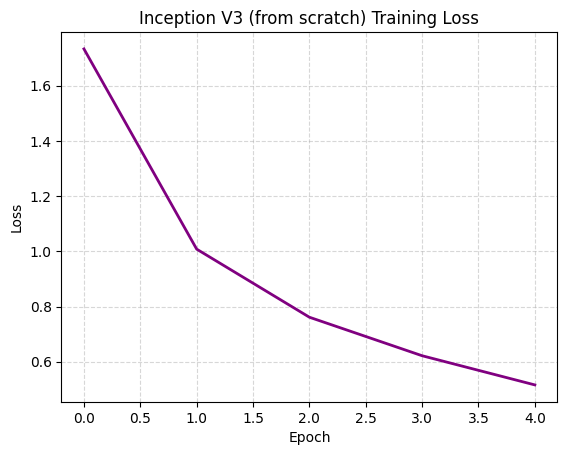

In [10]:
# Evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple): outputs = outputs[0]
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"\nTest Accuracy: {accuracy:.2f}%")

# Plot training loss
plt.plot(train_losses, color='purple', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Inception V3 (from scratch) Training Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()